# Offset Postprocessing
<br>

**Author:** Jack Logan

This notebook walks through the filtering steps used in `postprocess.py` to reduce noise in Sentinel-1 dense offset outputs. 
We recommend using this notebook as a sandbox to tune your postprocessing parameters before committing them to `config.json` and filtering the full dataset from the command line.

The steps are as follows:
1. Downsample to the effective resolution
2. Filter speckle using a threshold and localized Median Absolute Deviation (MAD) filter
3. Inpaint masked values using biharmonic interpolation
4. Transform to EPSG:3031 catersion coordinates
5. Convert to velocity in meters per year

Once you are happy with your parameters, update the `"postprocessing"` section of `config.json` and run `postprocess.py` to process the full stack.

### Import Packages

In [1]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from scipy.ndimage import median_filter
from scipy.interpolate import griddata
from shapely.geometry import Polygon
from skimage.restoration.inpaint import inpaint_biharmonic
from time import time

### Helper Functions

In [2]:
def plot_offsets(rg, az, amax=21):
    fig, axs = plt.subplots(1, 2, figsize=(10, 6), layout='constrained')
    ax1, ax2 = axs

    rg.plot(
        ax=ax1, vmin=-amax, vmax=amax, 
        cmap='RdBu_r', 
        add_colorbar=False
    )

    az.plot(
        ax=ax2, vmin=-amax, vmax=amax, 
        cmap='RdBu_r', 
        cbar_kwargs={'shrink':0.8, 'label':'Pixel Displacement'}
    )
    
    for ax in axs:
        ax.set_aspect('equal')
        ax.set_xlabel('x [m]')
        ax.set_ylabel('y [m]')
    
    return fig, axs

## Step 1: Downsample Resolution

The effective resolution is determined by the skip width and height.
With a skip size of 44 x 8, we achieve a resolution of ~ 100 m. 
ISCE2 outputs the files with a resolution of ~ 13 m, nearly an order of magnitude below our effective resolution.

To save memory and reduce computation costs, we can resample the data at our target resolution. 
In our processing, we are aiming for a grid resolution of 50 m. 

> We did a test between 50 m and 100 m effective resolution and found the 100 m resolution produced comparable results in approximately half the runtime.
> 
> Thus, our effective and target resolutions are not the same.

To resample the data, we use the xarray interpolation method, using a nearest neighbor interpolation scheme.

In [3]:
# . . Load in offsets from merged folder
offset_dir = 'offsets/20180819-20180831/'
off = xr.open_dataarray(offset_dir+'merged/dense_offsets.nc', engine='rasterio')

# . . Interpolate to the coords of the fracture dataset
xmin, xmax, nx = 1.345e6, 1.43e6, 1699  # bounds found manually
ymin, ymax, ny = 1.646e6, 1.76e6, 2279

off_interp = off.interp(
    coords={
    'x':np.linspace(xmin+50, xmax-50, nx),
    'y':np.linspace(ymin+50, ymax-50, ny)
    },
    method='nearest'  # Nearest neighbor
)

Next, break the band dimension into azimuth and range variables and visualize the offsets.
- Azimuth: Band 1
- Range: Band 2

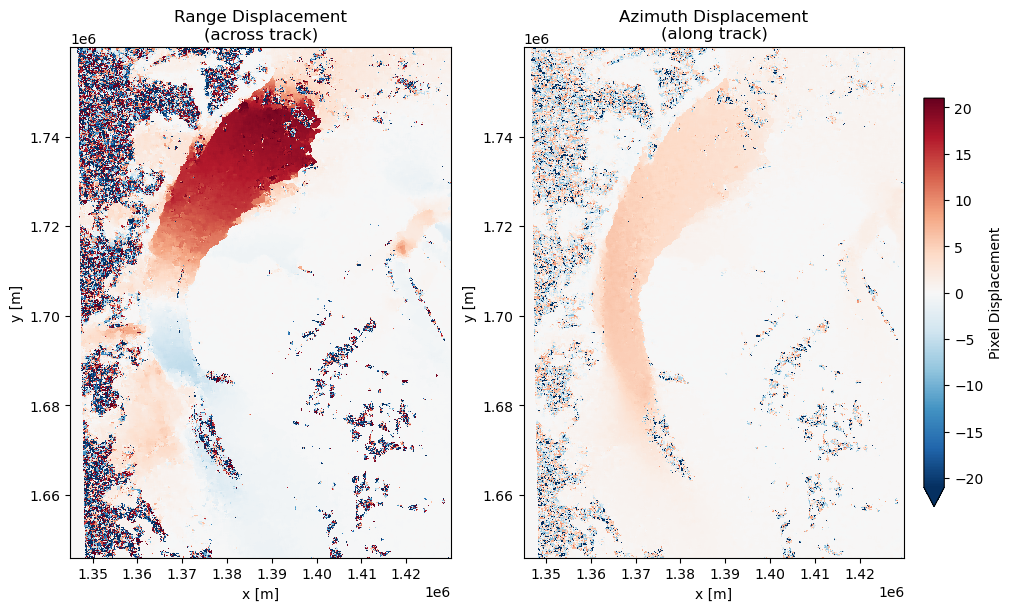

In [4]:
# Split bands into azimuth, range
rg = off_interp.sel(band=2)
az = off_interp.sel(band=1)

fig, axs = plot_offsets(rg, az)
ax1, ax2 = axs

ax1.set_title('Range Displacement\n(across track)')
ax2.set_title('Azimuth Displacement\n(along track)')

plt.show()

## Step 2: Filter Offsets

ISCE2 produces a lot of salt and pepper speckle. 
This happens frequently in low-velocity areas or when the correlation window cannot find a good match. 
We will filter this speckling using two criteria:
1. apply an amplitude threshold above the maximum observed displacement,
2. apply a localized median absolute deviation filter.

### A) Amplitude Threshold

To find the amplitude thresholds, we used histograms to determine the extent of "real" data.
The histograms below show the distribution of the offsets in the range and azimuth directions.

> Note the difference between number of pixels displaced in azimuth and range.
> This is another artifact of the resolution discrepancy between the directions with Sentinel-1. 

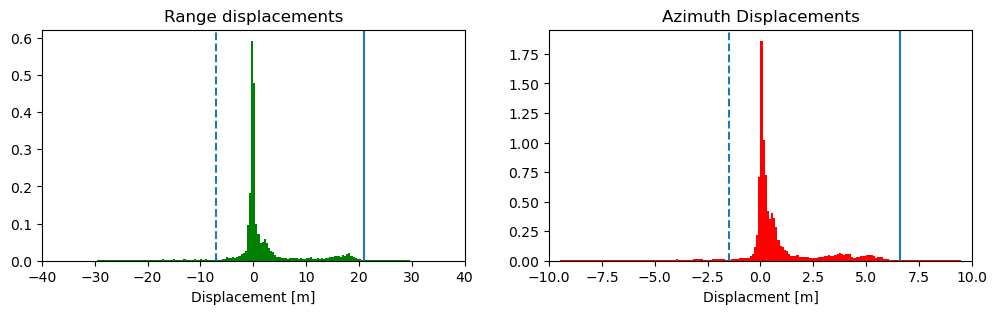

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

amax = 40
rg.plot.hist(ax=ax1, bins=200, range=[-amax, amax], color='g', density=True)
ax1.set_title('Range displacements')
ax1.set_xlabel('Displacement [m]')
ax1.set_xlim(-amax, amax)

# . . Change upper and lower bounds for your range
rg_max, rg_min = 21, -7
ax1.axvline(rg_min, ls='--', label='Lower Bound')
ax1.axvline(rg_max, label='Upper bound')

amax = 10
az.plot.hist(ax=ax2, bins=200, range=[-amax, amax], color='r', density=True)
ax2.set_title('Azimuth Displacements')
ax2.set_xlabel('Displacment [m]')
ax2.set_xlim(-amax, amax)

# . . Change upper and lower bounds for your azimuth
az_max, az_min = 6.6, -1.5
ax2.axvline(az_min, ls='--', label='Upper Bound')
ax2.axvline(az_max, label='Lower Bound')

plt.show()

Using the histograms above, find the value that looks like where teh "real" observations end, and where the speckle takes over. 
Real values tend to be have higher counts, the speckled observations will tpyically appear as a thin line along the x-axis.
You will likely have a non-normal distribution, and thus asymmetric thresholds.

The cell below plots the masked in grey over the offset maps. 
You can use this to refine the threshold you pick above.
Keep in mind that not all of the speckles will be masked &mdash; this behavior is expected and okay. 
The second criteria will cover the rest.

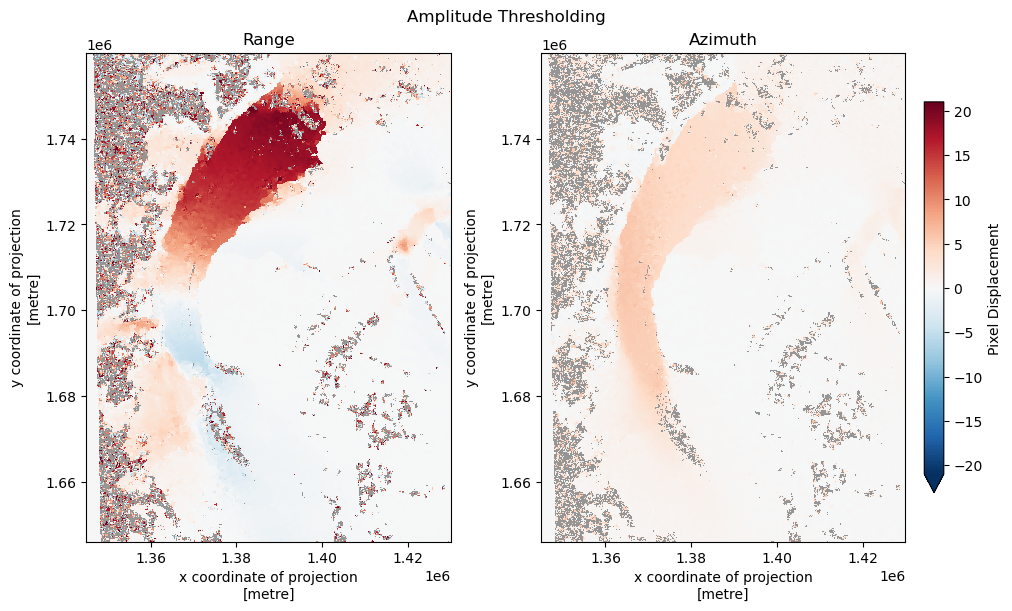

In [6]:
# . . Mask azimuth
thresh_mask_az = (az > az_max) + (az < az_min)

# . . Mask range
thresh_mask_rg = (rg > rg_max) + (rg < rg_min)

# . . Plot masks over data
fig, axs = plot_offsets(rg, az)
ax1, ax2 = axs

thresh_mask_rg.where(thresh_mask_rg, np.nan).plot(ax=ax1, add_colorbar=False, cmap='Greys')
ax1.set_title('Range')

thresh_mask_az.where(thresh_mask_az, np.nan).plot(ax=ax2, add_colorbar=False, cmap='Greys')
ax2.set_title('Azimuth')

plt.suptitle('Amplitude Thresholding')
plt.show()

### B) Median Absolute Deviation Filter

For this filter criteria, we implement a localized median absolute deviation (MAD).
Typically, a MAD criteria excludes values where the deviation of a pixel is greater than a scalar multiple of the MAD.
The MAD is defined as:
$$ MAD = median(|X - median(X)|),$$
which describes median deviation from the dataset's median.

In our dataset, we have a high spatial variability that dominates the median values. 
Instead of using a global median, we calculate the median value within a window around the point and compute the MAD from this window. 
The size of your windows depends on the noise of your data and the scale of spatial variations. 
For Shirase Glacier, we used 80 pixel square windows.
To localize the median absolute deviation, we use the following steps:

Our exclusion criteria are areas where $deviation > c * MAD$, where $c$ is a scalar.
The scalar gives some more tunability to the filter.
Smaller $c$ values throw away values more aggresively, while large $c$ values are more selective.

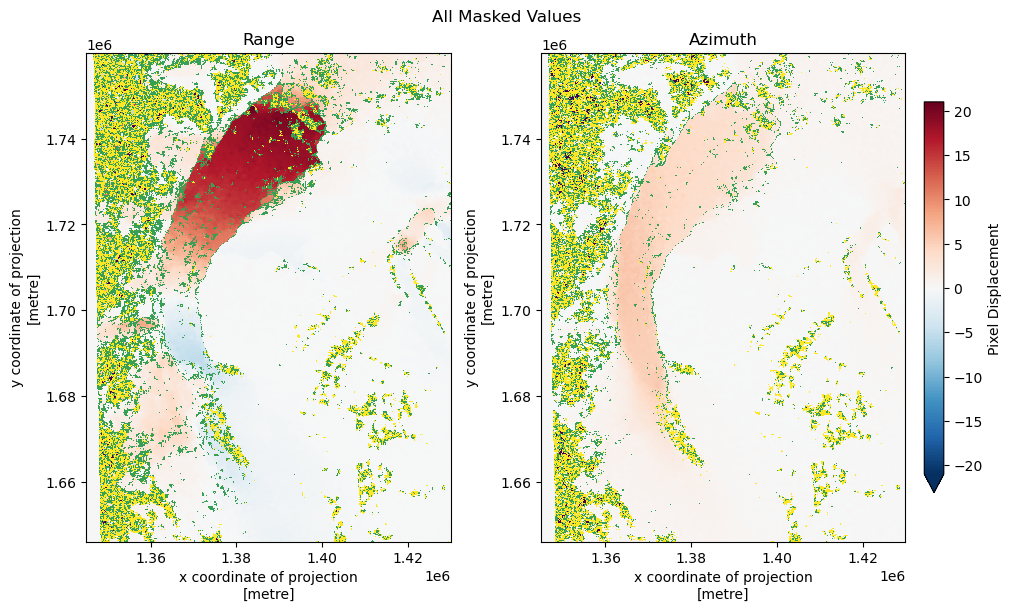

In [7]:
def mad_filter(arr, med=None, size=31, scale=10):
    # . . Apply median filter if not given
    if med is None:
        med = xr.apply_ufunc(
            median_filter,
            arr,
            kwargs={'size':size}
        )
    
    # . . Compute difference between raw and filtered data
    diff = np.abs(arr - med)
    
    # . . Compute MAD (median of diff) of data
    mad = diff.median(skipna=True)
    
    # . . Threshold by a scale multiple of MAD
    mad_mask = (diff > (mad * scale))
    return mad_mask, med

# . . Apply MAD filter to each band
mad_mask_az, med_az = mad_filter(az, size=31, scale=10)
mad_mask_rg, med_rg = mad_filter(rg, size=31, scale=10)

# . . Plot the masks
fig, axs = plot_offsets(rg, az)
ax1, ax2 = axs

thresh_mask_rg.where(thresh_mask_rg).plot(ax=ax1, cmap='Greys', vmax=1, vmin=0, add_colorbar=False)
mad_mask_rg.where(mad_mask_rg).plot(ax=ax1, cmap='Greens', vmax=1.5, vmin=0, add_colorbar=False)
mad_mask_rg.where(thresh_mask_rg).plot(ax=ax1, vmax=1, vmin=0, add_colorbar=False)  # Both masks

ax1.set_title('Range')

thresh_mask_az.where(thresh_mask_az).plot(ax=ax2, cmap='Greys', vmax=1, vmin=0, add_colorbar=False)
mad_mask_az.where(mad_mask_az).plot(ax=ax2, cmap='Greens', vmax=1.5, vmin=0, add_colorbar=False)
mad_mask_az.where(thresh_mask_az).plot(ax=ax2, vmax=1, vmin=0, add_colorbar=False)  # Both masks

ax2.set_title('Azimuth')

plt.suptitle('All Masked Values')
plt.show()

> The thresholded values are in black, the MAD values are in green. Pixels discarded by both filters are in yellow.

The majority of points are yellow, indicating they were flagged by both filters. 
There are, however, a handful of pixels where both filters are required to mask noise.
They are primarily in speckled regions.

The MAD filter can be a little bit aggresive in the shear margins. Use your discretion 

### C) Mask Bad points

Remove the masked values and replace with the value of the large median filter from the MAD filtering step.

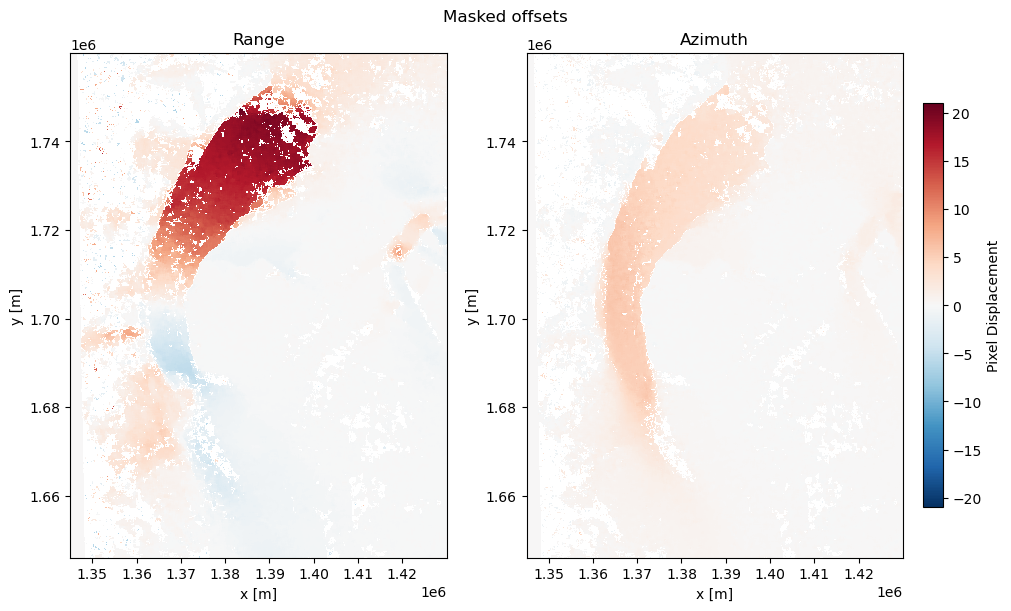

In [8]:
# . . Mask data, impute with median filtered value
full_mask_az = thresh_mask_az + mad_mask_az
az_masked = az.where(~full_mask_az, np.nan)

full_mask_rg = thresh_mask_rg + mad_mask_rg
rg_masked = rg.where(~full_mask_rg, np.nan)

fig, axs = plot_offsets(rg_masked, az_masked)
ax1, ax2 = axs

ax1.set_title('Range')
ax2.set_title('Azimuth')

plt.suptitle('Masked offsets')
plt.show()

## Step 3: Inpaint masked values

We replace the masked values using biharmonic inpainting. 
This method is gradient aware and preserves local structure very well, making it an ideal method for restoring discarded values.
Most of the discarded points above are along shear margins or speckled points.
While we don't care about the noise ocurring outside the main region of interest, the structure along the shear margins and in the main channel is important to maintain. 

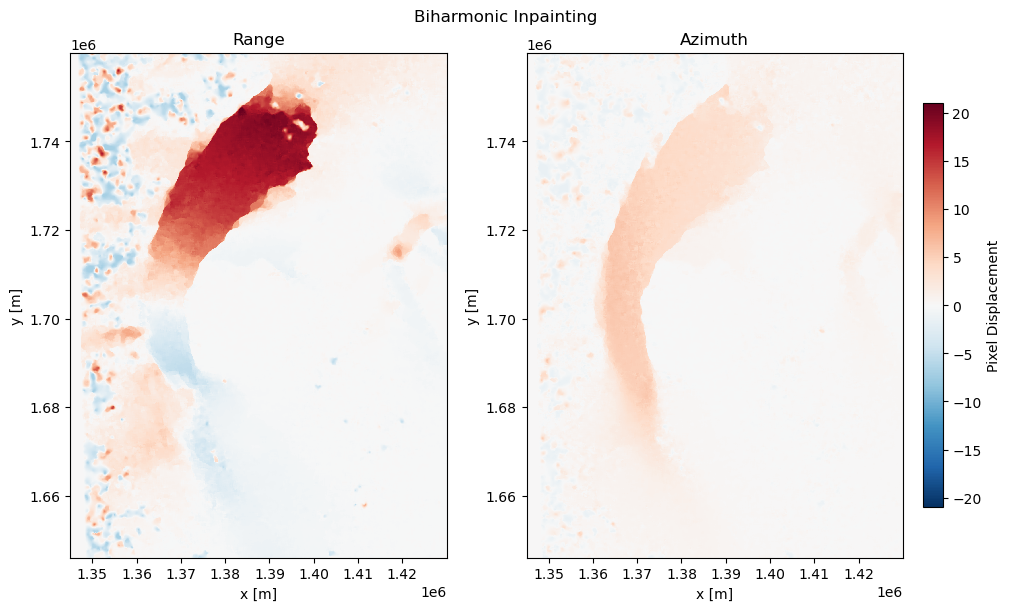

In [9]:
az_inpaint = xr.apply_ufunc(
    inpaint_biharmonic,
    az,
    full_mask_az
)

rg_inpaint = xr.apply_ufunc(
    inpaint_biharmonic,
    rg,
    full_mask_rg
)

fig, axs = plot_offsets(rg_inpaint, az_inpaint)
ax1, ax2 = axs

ax1.set_title('Range')
ax2.set_title('Azimuth')

plt.suptitle('Biharmonic Inpainting')
plt.show()

## Step 4: Transform coordinates

Now we will convert from from azimuth-range-coordingates to EPSG:3031 xy-coordinates. To do this, we need to get the satellites heading in reference to the grid system. We will do that from the bounding box.

From one of the SAFE zip files, you can extract the bounding box of the Sentinel-1 frame. For Shirase Glacier, the WKT is:
```
'POLYGON ((1261309.4671252735 1775874.4512153463, 1513081.2203376407 1778324.8702692143, 1513619.2870697696 1592810.3581539085, 1262580.7035495376 1591567.5236746788, 1261309.4671252735 1775874.4512153463))'
```
Because Sentinel-1 is a right-looking satellite, we can assume it was travelling from bottom to top off the left-edge of the screen.

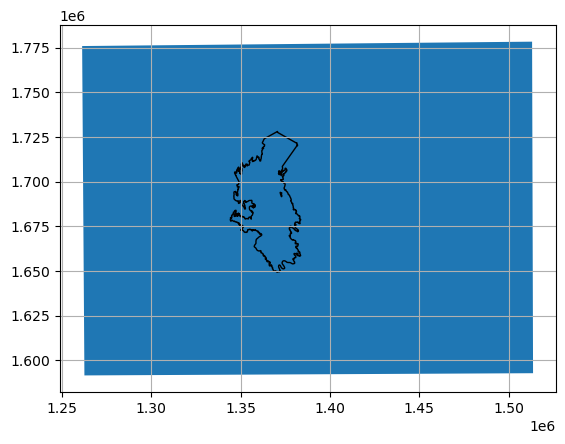

In [10]:
# . . Shirase Glacier shapefile
shirase = gpd.read_file('./data/shirase.shp')

# . . Make GeoDataFrame of bounding box
wkt = 'POLYGON ((1261309.4671252735 1775874.4512153463, 1513081.2203376407 1778324.8702692143, 1513619.2870697696 1592810.3581539085, 1262580.7035495376 1591567.5236746788, 1261309.4671252735 1775874.4512153463))'
s1_frame = gpd.GeoSeries.from_wkt(
    [wkt],
    crs='EPSG:3031'
)

# . . Plot for comparison
fig, ax = plt.subplots()

s1_frame.to_crs(3031).plot(ax=ax)
shirase.plot(ax=ax, fc='none')
plt.grid()
plt.show()

Now we can calculate the satellite's heading (in radians) from the positive x-axis.

In [11]:
def get_satellite_geometry(wkt):
    """Get satellite angle in EPSG:3031 from preview KML file"""
    bbox = gpd.GeoSeries.from_wkt(
        [wkt],
        crs='EPSG:3031'
    )

    # Get coordinates of bbox
    coords = list(bbox.geometry[0].exterior.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[1]

    # Compute angle in radians
    return np.arctan2(y2-y1, x2-x1)

heading = get_satellite_geometry(wkt)
print(heading)

0.009732393148339494


Before we rotate the displacements to cartesian coordinates, we need to scale the offset values. They are currently given as number of pixels in the azimuth and range directions. To get the displacement in meters, we must scale by the directional resolution:

$$y = (\text{azimuth offset}) \times 14.1 \text{ m}, \quad x = (\text{range offset}) * \frac{2.3}{\sin{\theta}} \text{ m}.$$

Then, we can do a coordinate transformation to get the offsets in xy-coordinates.

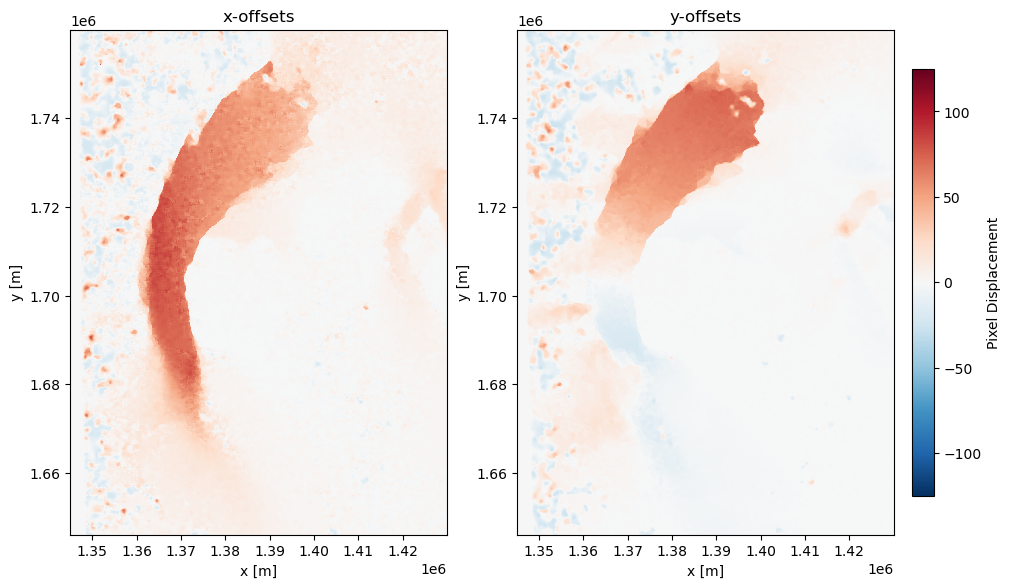

In [12]:
# . . Multiply offsets by resolution to get disp in meters
az_inpaint *= 14.1
rg_inpaint *= 2.3 / np.sin(np.radians(38.3)) # Ground-range (only horizontal)

# . . Coordinate transformation
x_offsets = np.cos(heading) * rg_inpaint - np.sin(heading) * az_inpaint
y_offsets = np.cos(heading) * az_inpaint + np.sin(heading) * rg_inpaint

fig, axs = plot_offsets(y_offsets, x_offsets, amax=125)
ax1, ax2 = axs

ax1.set_title('x-offsets')
ax2.set_title('y-offsets')

plt.show()

## Step 5: Convert to velocity

Now we have our displacements in meters. This occurred over a 12 day span, so to scale to velocity in meters per year, we have to do a simple unit conversion.

Divide by the number of days between satellite passes to get velocity in meters per day, then scale by 365.24 days per year.

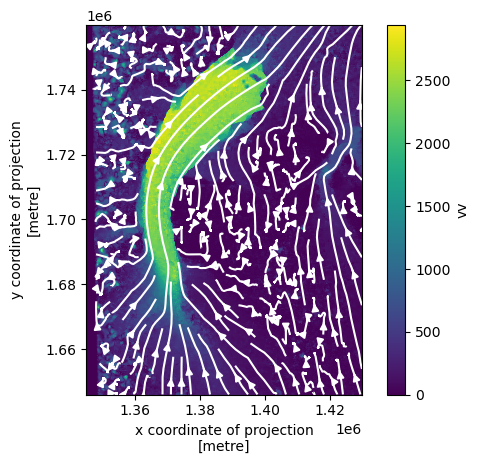

In [14]:
# . . Convert to meters / year
vx = x_offsets * 365.24 / 12
vy = y_offsets * 365.24 / 12

# . . Unit conversion to velocity, saved in dataset
velocity = xr.Dataset({
    'vx':vx,
    'vy':vy,
    'vv':np.sqrt(vx**2 + vy**2)
})

# . . Plot velocity magnitude with streamlines
fig, ax = plt.subplots()

velocity.vv.plot(ax=ax)
velocity.plot.streamplot(
    x='x',  y='y',
    u='vx', v='vy',
    ax=ax, color='w'
)
ax.set_title(None)
ax.set_aspect('equal')

plt.show()

## Postprocess all Offsets

I recommend figuring out your postprocessing parameters, like the amplitude thresholds, MAD mask size and scalar, and median filter size, in this notebook while you compute the bulk of your offsets.
Once you have settled on your preferred values, update the parameters in the `"postprocessing"` section of `config.json`.


To postprocess all offsets, run `postprocess.py` from the command line, passing your updated config file as an argument.
```bash
python postprocess.py config.json
```

> **NOTE:** Azimuth and range bounds are normalized to pixels per day.

The first time you run the script, set the `"stack": true` in the config. This will read all the offset directories, interpolate them onto a common grid, and stack them along a `mid_date` time dimension into a single dataset.

Once stacked, the script applies your cleaning parameters and a final 3-dimensional median filter before converting to velocity

Our default filter size is 3 in the time dimension (~1 month) and 7 spatially (~350 m) &ndash; adjust `"temporal_filter"` in the config if your dataset has different temporal sampling or resolution.